In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df2= pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv')
df2

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [5]:
print(df.shape)

df.info()

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
162    False
163    False
164    False
165    False
166    False
Length: 167, dtype: bool

# EDA

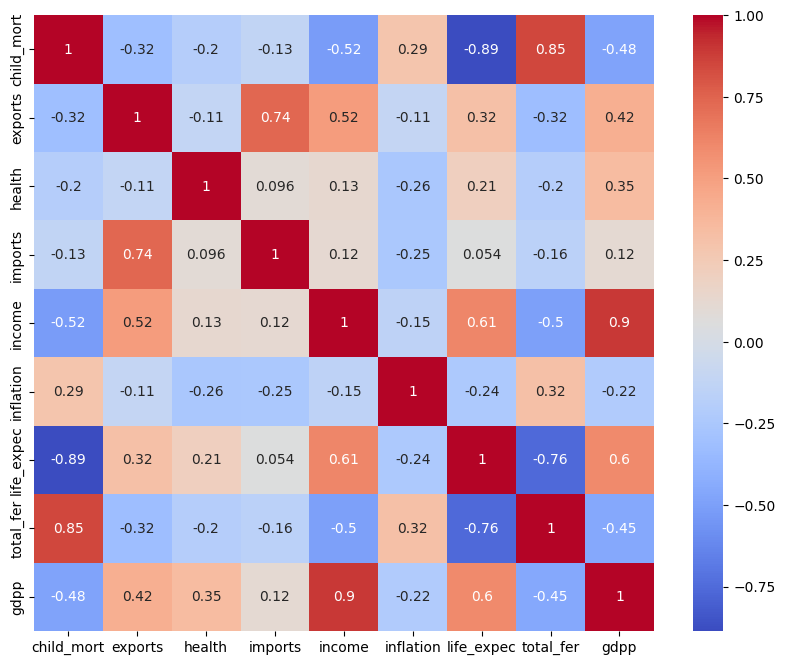

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(df.drop('country',axis=1).corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

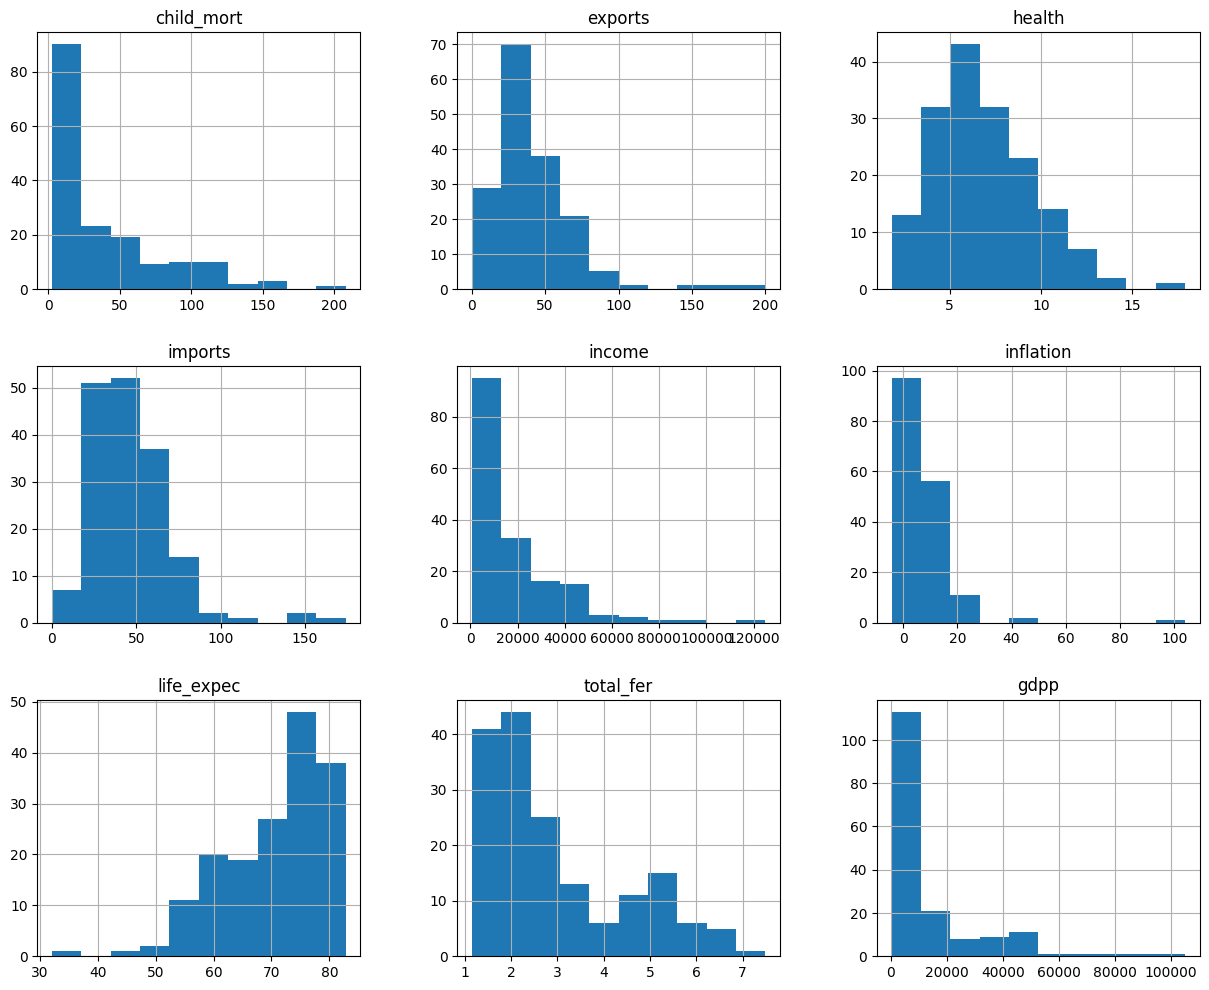

In [10]:
df.hist(figsize=(15,12))
plt.show()

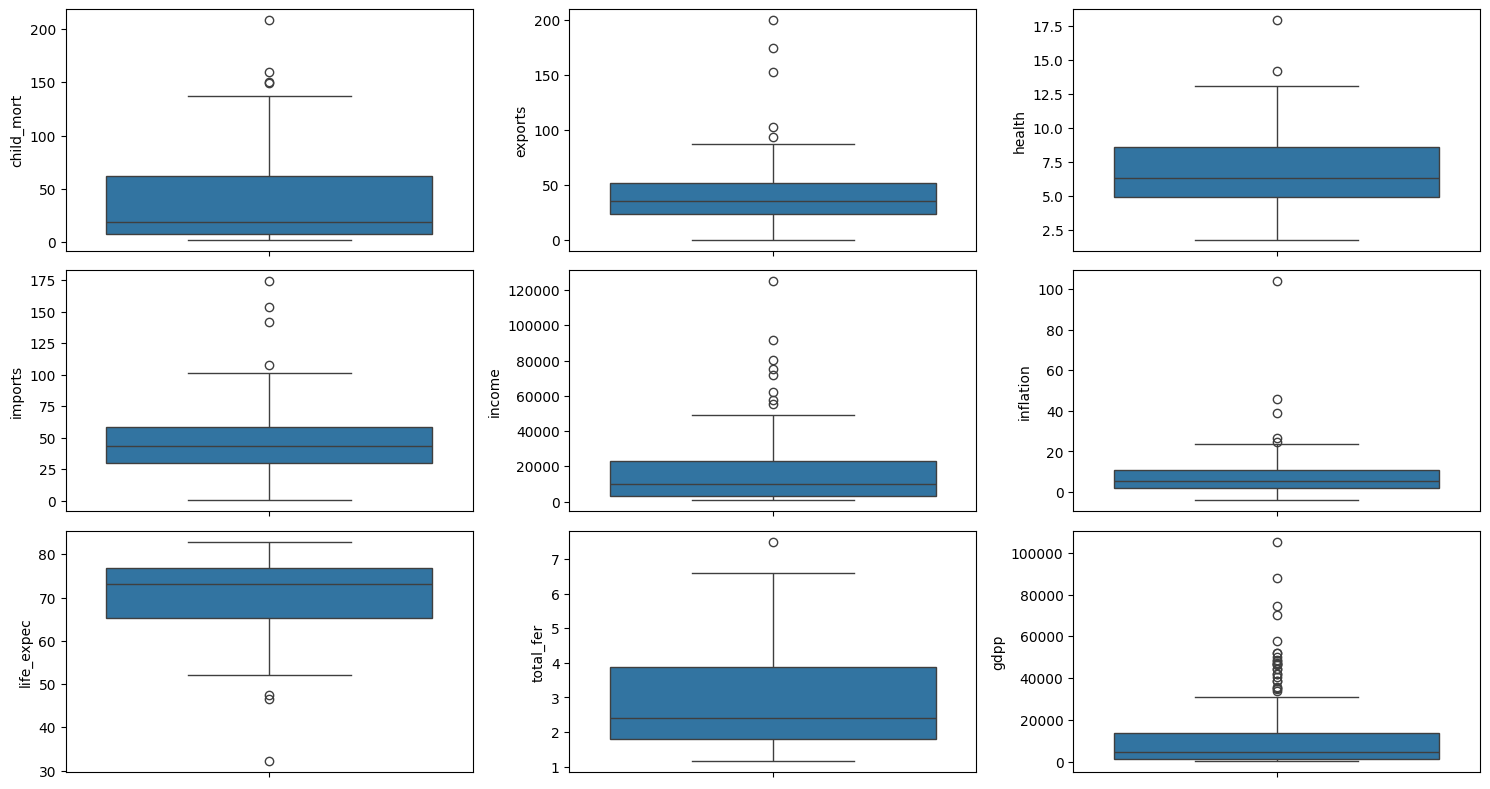

In [11]:
plt.figure(figsize=(15,8))

for i,col in enumerate(df.columns[1:]):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

# PHASE 2 : Feature Preparation

In [12]:
country = df['country']

X = df.drop('country',axis=1)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PHASE 3 : K-Means Clustering

**Find Optimal K**

In [14]:
wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,
                  random_state=42)
    
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

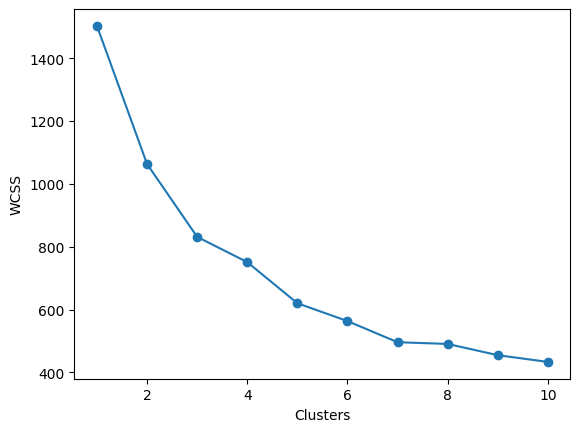

In [15]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

**Kmeans Clustering**

In [16]:
kmeans=KMeans(n_clusters=3,
              random_state=42)

clusters=kmeans.fit_predict(X_scaled)

df['Cluster']=clusters

In [17]:
df['Cluster'].value_counts()

Cluster
0    86
2    45
1    36
Name: count, dtype: int64

In [18]:
df.groupby('Cluster').mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


**Clustering segmented countries into three distinct groups.**
* Cluster 1 represents developed economies characterized by high income, high GDP, and low child mortality.
* Cluster 0 contains developing nations with moderate socio-economic indicators.
* Cluster 2 consists of underdeveloped countries exhibiting low income, low GDP, high fertility, and high child mortality, indicating that these countries should be prioritized for humanitarian assistance and development programs.

In [19]:
df[df['Cluster']==0]['country']

1                  Albania
2                  Algeria
4      Antigua and Barbuda
5                Argentina
6                  Armenia
              ...         
160                Uruguay
161             Uzbekistan
162                Vanuatu
163              Venezuela
164                Vietnam
Name: country, Length: 86, dtype: object

In [20]:
df[df['Cluster']==1]['country']

7                 Australia
8                   Austria
11                  Bahrain
15                  Belgium
23                   Brunei
29                   Canada
42                   Cyprus
43           Czech Republic
44                  Denmark
53                  Finland
54                   France
58                  Germany
60                   Greece
68                  Iceland
73                  Ireland
74                   Israel
75                    Italy
77                    Japan
82                   Kuwait
91               Luxembourg
98                    Malta
110             Netherlands
111             New Zealand
114                  Norway
122                Portugal
123                   Qatar
133               Singapore
134         Slovak Republic
135                Slovenia
138             South Korea
139                   Spain
144                  Sweden
145             Switzerland
157    United Arab Emirates
158          United Kingdom
159           United

In [21]:
df[df['Cluster']==2]['country']

0                   Afghanistan
3                        Angola
17                        Benin
25                 Burkina Faso
26                      Burundi
28                     Cameroon
31     Central African Republic
32                         Chad
36                      Comoros
37             Congo, Dem. Rep.
38                  Congo, Rep.
40                Cote d'Ivoire
49            Equatorial Guinea
50                      Eritrea
55                        Gabon
56                       Gambia
59                        Ghana
63                       Guinea
64                Guinea-Bissau
66                        Haiti
80                        Kenya
81                     Kiribati
84                          Lao
87                      Lesotho
88                      Liberia
93                   Madagascar
94                       Malawi
97                         Mali
99                   Mauritania
106                  Mozambique
108                     Namibia
112     

# PHASE 4 : PCA Visualization

In [22]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

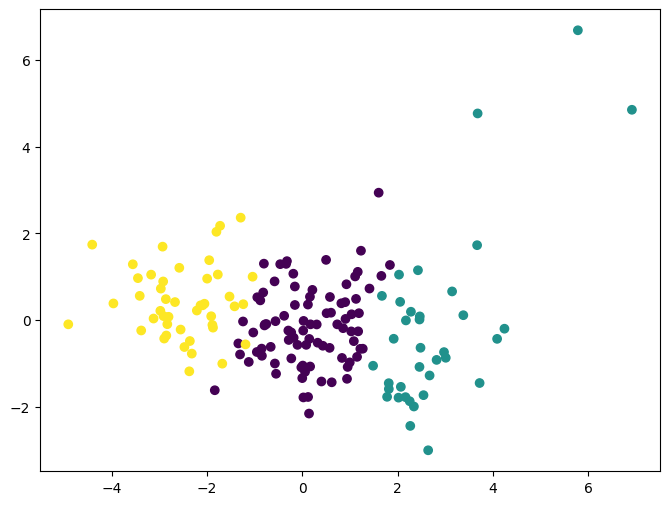

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=clusters,
            cmap='viridis')

plt.show()

# PHASE 5 : DBSCAN

In [24]:
dbscan=DBSCAN(eps=1.5,
              min_samples=5)

db_labels=dbscan.fit_predict(X_scaled)

df['DBSCAN']=db_labels

# PHASE 6 : Classification

In [25]:
X=df.drop(['country','Cluster','DBSCAN'],
          axis=1)

y=df['Cluster']

In [26]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42)

# PHASE 7 : Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# PHASE 8 : Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf= RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

In [33]:
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# PHASE 9 : XGBoost

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

# Predict
pred_xgb = xgb.predict(X_test)

# Evaluate
print(classification_report(y_test, pred_xgb))
print("Accuracy:", accuracy_score(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Accuracy: 1.0


# Compare All Models

In [38]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy :", accuracy_score(y_test, pred_dt))
print("Random Forest Accuracy :", accuracy_score(y_test, pred_rf))
print("XGBoost Accuracy       :", accuracy_score(y_test, pred_xgb))

Decision Tree Accuracy : 1.0
Random Forest Accuracy : 1.0
XGBoost Accuracy       : 1.0


# FINAL BUSINESS INSIGHTS
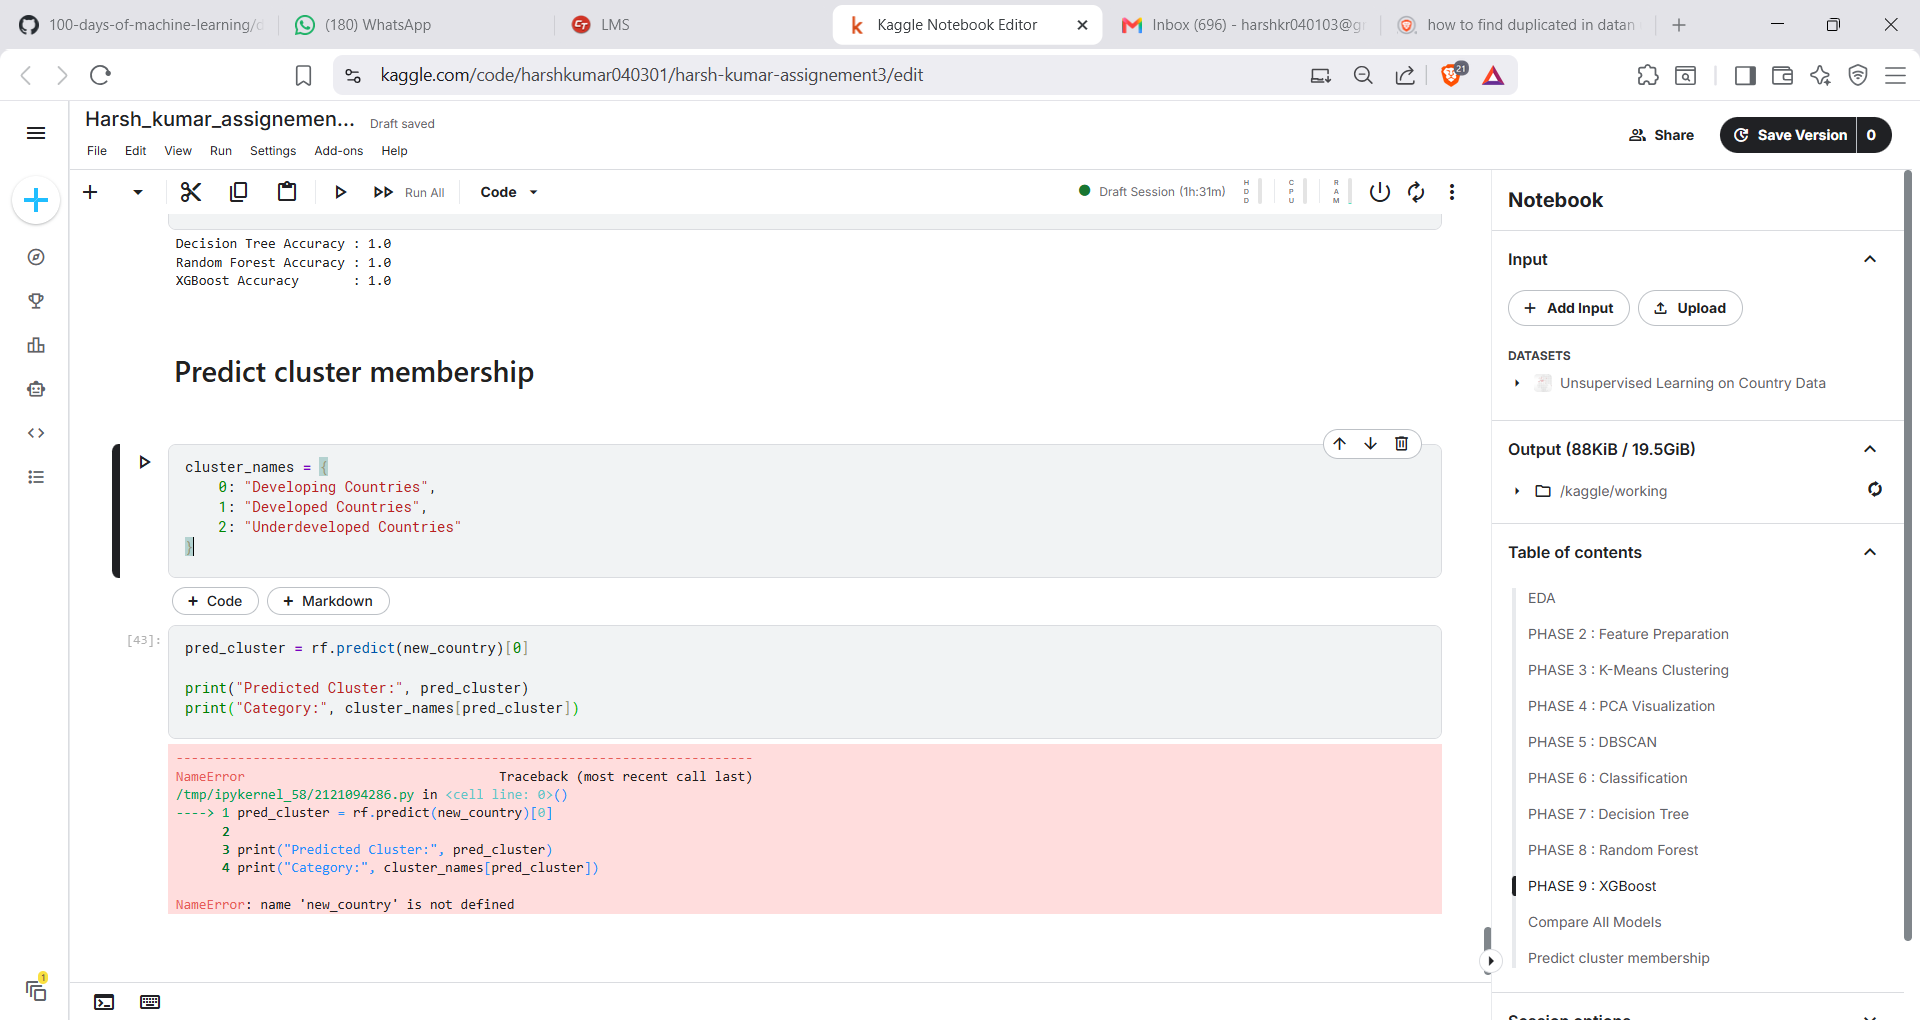

* Countries with low income, low GDP, high fertility, and high child mortality are more vulnerable and should be prioritized for humanitarian assistance.
* Outliers should not be removed because they correspond to countries facing the greatest developmental challenges and are the primary targets for aid programs.


**Countries Naturally Form Three Distinct Segments**

**Cluster 1 – Developed Countries**

Characteristics:

* High income and GDP
* Low child mortality
* High life expectancy
* Low fertility rates

Aid Priority: Low

**Cluster 0 – Developing Countries**

Characteristics:

* Moderate economic indicators

* Moderate mortality and fertility rates

* Reasonable life expectancy

Aid Priority: Medium



**Cluster 2 – Underdeveloped Countries**

Characteristics:


* Low income and GDP
* High child mortality
* Low life expectancy
* High fertility rates


Aid Priority: Highest

**Business Insight**

HELP International should concentrate its resources on Cluster 2 countries, where healthcare and economic conditions are weakest.